In [1]:
import os
import sys
from pathlib import Path

import shap
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_fontja  # noqa: F401
import lightgbm as lgb

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pd.set_option("display.max_columns", None)

In [13]:
# 予測データフレームを読み込み
path = "../outputs/test_predictions.csv"
df = pd.read_csv(path)
df

,original_index,種類,価格情報区分,市区町村コード,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,面積（㎡）,建築年,建物の構造,用途,今後の利用目的,都市計画,建ぺい率（％）,容積率（％）,改装,築年数,最寄駅：緯度,最寄駅：経度,住所,room_count,has_L,has_D,has_K,has_S,取引四半期,log_面積,log_最寄駅：距離,築年数^2,中心地_距離,山手線内側,容積消化率（％）,log_建ぺい率,log_容積率,容積距離,log_取引価格,actual_log_price,pred_log_price,actual_price_yen,pred_price_yen,error_yen,abs_error_yen,error_rate_percent,ape_percent,actual_price_band
0,37793,中古マンション等,1,13213,久米川,4.0,54000000,75,2024.0,RC,住宅,住宅,商業系,60.0,200.0,NaN,2.0,35.749575,139.472653,東京都東村山市栄町,3.0,1,1,1,0,4,4.317488,1.386294,4.0,27.650228,0,3.333333,4.094345,5.298317,800.0,17.804495,17.804495,17.858969,54000000,57023241,3023241,3023241,5.598595,5.598595,5000万~1億
1,32707,中古マンション等,1,13123,船堀,5.0,69000000,75,2011.0,RC,住宅,住宅,商業系,60.0,200.0,NaN,15.0,35.683795,139.864258,東京都江戸川区船堀,3.0,1,1,1,0,3,4.317488,1.609438,225.0,8.777604,0,3.333333,4.094345,5.298317,1000.0,18.049617,18.049617,18.062239,69000000,69876452,876452,876452,1.270221,1.270221,5000万~1億
2,14320,中古マンション等,0,13109,大崎,6.0,180000000,100,1998.0,SRC,住宅,住宅,工業系,60.0,300.0,NaN,28.0,35.619772,139.728439,東京都品川区大崎,4.0,1,1,1,0,1,4.605170,1.791759,784.0,7.676502,0,5.000000,4.094345,5.703782,1800.0,19.008467,19.008467,18.841800,180000000,152366547,-27633453,27633453,-15.351918,15.351918,1億~3億
3,30352,中古マンション等,1,13121,竹ノ塚,3.0,70000000,100,2005.0,RC,住宅,住宅,商業系,80.0,300.0,NaN,21.0,35.794368,139.790788,東京都足立区西竹の塚,4.0,1,1,1,0,1,4.605170,1.098612,441.0,12.759717,0,3.750000,4.382027,5.703782,900.0,18.064006,18.064006,17.770471,70000000,52193644,-17806356,17806356,-25.437652,25.437652,5000万~1億
4,7787,中古マンション等,1,13106,蔵前,2.0,36000000,30,2023.0,RC,住宅,住宅,商業系,80.0,700.0,NaN,3.0,35.703236,139.790931,東京都台東区駒形,1.0,0,1,1,0,2,3.401197,0.693147,9.0,3.256734,0,8.750000,4.382027,6.551080,1400.0,17.399029,17.399029,17.566095,36000000,42545936,6545936,6545936,18.183156,18.183156,2000万~5000万
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7927,10747,中古マンション等,1,13108,豊洲,5.0,150000000,80,2009.0,RC,住宅,住宅,工業系,60.0,200.0,NaN,17.0,35.654908,139.796210,東京都江東区豊洲,3.0,1,1,1,0,1,4.382027,1.609438,289.0,3.933675,0,3.333333,4.094345,5.298317,1000.0,18.826146,18.826146,18.783767,150000000,143776009,-6223991,6223991,-4.149327,4.149327,1億~3億
7928,28338,中古マンション等,0,13119,ときわ台,11.0,18000000,20,2007.0,RC,住宅,住宅,住居系,60.0,200.0,NaN,19.0,35.758771,139.689015,東京都板橋区常盤台,NaN,0,0,0,0,3,2.995732,2.397895,361.0,11.137966,0,3.333333,4.094345,5.298317,2200.0,16.705882,16.705882,16.973213,18000000,23516507,5516507,5516507,30.647262,30.647262,~2000万
7929,20174,中古マンション等,0,13112,三軒茶屋,4.0,22000000,20,1998.0,RC,住宅,住宅,商業系,80.0,200.0,0.0,28.0,35.643716,139.670156,東京都世田谷区太子堂,1.0,0,0,1,0,2,2.995732,1.386294,784.0,9.703096,0,2.500000,4.382027,5.298317,800.0,16.906553,16.906553,16.999243,22000000,24136676,2136676,2136676,9.712163,9.712163,2000万~5000万
7930,30865,中古マンション等,1,13121,五反野,10.0,8000000,45,1977.0,鉄骨造,住宅,住宅,工業系,60.0,200.0,NaN,49.0,35.765852,139.809643,東京都足立区中央本町,2.0,1,1,1,0,1,3.806662,2.302585,2401.0,10.161633,0,3.333333,4.094345,5.298317,2000.0,15.894952,15.894952,16.545900,8000000,15338856,7338856,7338856,91.735703,91.735703,~2000万


In [3]:
# カラムの確認
print(df.columns.to_list())

['original_index', '種類', '価格情報区分', '市区町村コード', '最寄駅：名称', '最寄駅：距離（分）', '取引価格（総額）', '面積（㎡）', '建築年', '建物の構造', '用途', '今後の利用目的', '都市計画', '建ぺい率（％）', '容積率（％）', '改装', '築年数', '最寄駅：緯度', '最寄駅：経度', '住所', 'room_count', 'has_L', 'has_D', 'has_K', 'has_S', '取引四半期', 'log_面積', 'log_最寄駅：距離', '築年数^2', '中心地_距離', '山手線内側', '容積消化率（％）', 'log_建ぺい率', 'log_容積率', '容積距離', 'log_取引価格', 'actual_log_price', 'pred_log_price', 'actual_price_yen', 'pred_price_yen', 'error_yen', 'abs_error_yen', 'error_rate_percent', 'ape_percent', 'actual_price_band']


## 低額帯物件の分析

In [4]:
# 取引価格（総額）を2000万円未満に絞る
df_low_price = df[df["取引価格（総額）"] < 20000000]
print(f"低額帯のサンプル数: {len(df_low_price)}")
display(df_low_price.head())

低額帯のサンプル数: 913


,original_index,種類,価格情報区分,市区町村コード,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,面積（㎡）,建築年,建物の構造,用途,今後の利用目的,都市計画,建ぺい率（％）,容積率（％）,改装,築年数,最寄駅：緯度,最寄駅：経度,住所,room_count,has_L,has_D,has_K,has_S,取引四半期,log_面積,log_最寄駅：距離,築年数^2,中心地_距離,山手線内側,容積消化率（％）,log_建ぺい率,log_容積率,容積距離,log_取引価格,actual_log_price,pred_log_price,actual_price_yen,pred_price_yen,error_yen,abs_error_yen,error_rate_percent,ape_percent,actual_price_band
20,31272,中古マンション等,0,13121,六町,21.0,15000000,50,1979.0,SRC,店舗,住宅,住居系,60.0,200.0,0.0,47.0,35.784963,139.821816,東京都足立区神明,NaN,0,0,0,0,3,3.912023,3.044522,2209.0,12.545934,0,3.333333,4.094345,5.298317,4200.0,16.523561,16.523561,16.314538,15000000,12170647,-2829353,2829353,-18.862350,18.862350,~2000万
22,24452,中古マンション等,1,13116,池袋,13.0,17000000,25,1984.0,RC,住宅,住宅,商業系,80.0,400.0,NaN,42.0,35.730256,139.711086,東京都豊島区池袋,1.0,0,0,1,0,2,3.218876,2.564949,1764.0,7.437329,1,5.000000,4.382027,5.991465,5200.0,16.648724,16.648724,16.540066,17000000,15249627,-1750373,1750373,-10.296314,10.296314,~2000万
23,37774,中古マンション等,1,13213,所沢,5.0,14000000,55,1990.0,RC,住宅,住宅,工業系,50.0,100.0,NaN,36.0,NaN,NaN,東京都東村山市青葉町,3.0,0,1,1,0,3,4.007333,1.609438,1296.0,NaN,0,2.000000,3.912023,4.605170,500.0,16.454568,16.454568,16.281729,14000000,11777818,-2222182,2222182,-15.872725,15.872725,~2000万
24,18552,中古マンション等,1,13112,二子玉川,9.0,16000000,35,1976.0,鉄骨造,住宅,住宅,商業系,60.0,200.0,NaN,50.0,35.611788,139.626685,東京都世田谷区玉川,2.0,0,1,1,0,2,3.555348,2.197225,2500.0,14.855093,0,3.333333,4.094345,5.298317,1800.0,16.588099,16.588099,16.378775,16000000,12978114,-3021886,3021886,-18.886789,18.886789,~2000万
37,17018,中古マンション等,1,13111,西馬込,8.0,19000000,25,2003.0,RC,住宅,住宅,住居系,60.0,300.0,NaN,23.0,35.586859,139.705942,東京都大田区南馬込,1.0,0,0,1,0,3,3.218876,2.079442,529.0,11.861830,0,5.000000,4.094345,5.703782,2400.0,16.759950,16.759950,16.738114,19000000,18589628,-410372,410372,-2.159855,2.159855,~2000万


In [5]:
# 最寄駅：名称 の割合を上位10件表示
top_stations = df_low_price["最寄駅：名称"].value_counts()
print(top_stations)
print(top_stations.head(10))  # 上位10件を表示

最寄駅：名称
八王子      17
花小金井     15
立川       15
河辺       15
京王八王子    12
         ..
浮間舟渡      1
芝浦ふ頭      1
調布        1
分倍河原      1
新馬場       1
Name: count, Length: 330, dtype: int64
最寄駅：名称
八王子      17
花小金井     15
立川       15
河辺       15
京王八王子    12
西八王子     11
池袋       10
京王永山     10
国領       10
東青梅      10
Name: count, dtype: int64


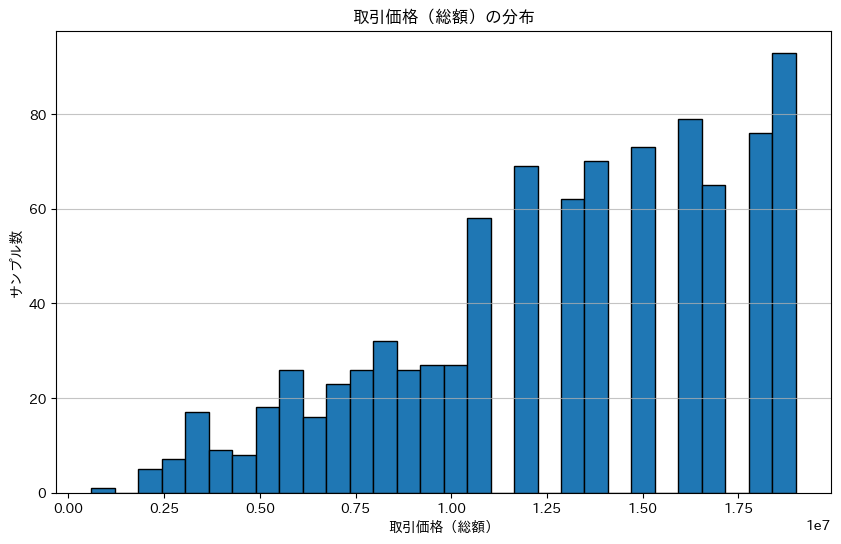

In [6]:
# 取引総額の分布
plt.figure(figsize=(10, 6))
plt.hist(df_low_price["取引価格（総額）"], bins=30, edgecolor="k")
plt.title("取引価格（総額）の分布")
plt.xlabel("取引価格（総額）")
plt.ylabel("サンプル数")
plt.grid(axis="y", alpha=0.75)
plt.show()

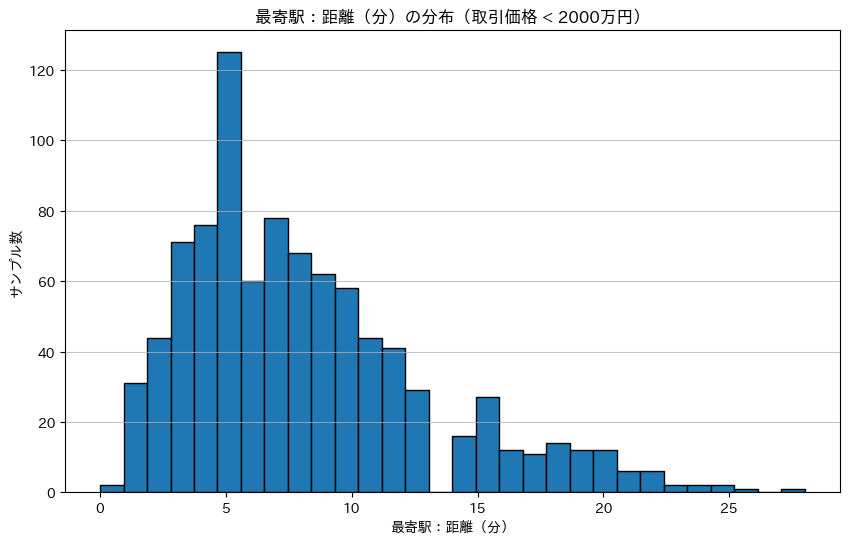

In [7]:
# 最寄駅：距離（分） の分布をヒストグラムで表示
plt.figure(figsize=(10, 6))
plt.hist(df_low_price["最寄駅：距離（分）"], bins=30, edgecolor="k")
plt.title("最寄駅：距離（分）の分布（取引価格 < 2000万円）")
plt.xlabel("最寄駅：距離（分）")
plt.ylabel("サンプル数")
plt.grid(axis="y", alpha=0.75)
plt.show()

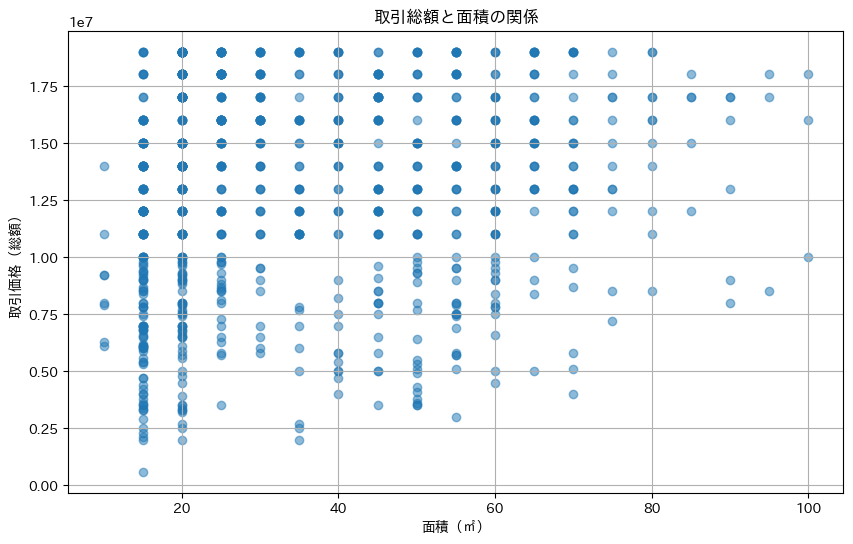

In [8]:
# 取引価格と面積の関係を散布図で表示
plt.figure(figsize=(10, 6))
plt.scatter(df_low_price["面積（㎡）"], df_low_price["取引価格（総額）"], alpha=0.5)
plt.title("取引総額と面積の関係")
plt.xlabel("面積（㎡）")
plt.ylabel("取引価格（総額）")
plt.grid()
plt.show()

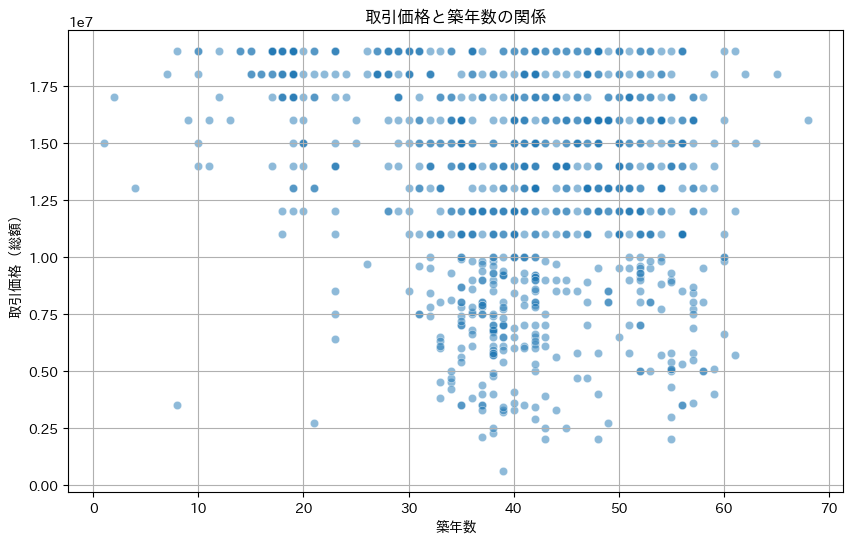

In [9]:
# 取引価格と築年数の関係
plt.figure(figsize=(10, 6))
sns.scatterplot(x="築年数", y="取引価格（総額）", data=df_low_price, alpha=0.5)
plt.title("取引価格と築年数の関係")
plt.xlabel("築年数")
plt.ylabel("取引価格（総額）")
plt.grid()
plt.show()

## 説明性確認

In [10]:
# 特徴量重要度の確認

# モデルの読み込み
with open("../models/lgbm_model.pkl", "rb") as f:
    model = pickle.load(f)

print(type(model))

# Booster を取得
booster = model.booster_ if hasattr(model, "booster_") else model

feat_names = booster.feature_name()

imp = pd.DataFrame({
    "feature": feat_names,
    "gain":  booster.feature_importance(importance_type="gain"),
    "split": booster.feature_importance(importance_type="split"),
})

# gain の比率を確認
imp["gain_ratio"] = imp["gain"] / imp["gain"].sum()
imp = imp.sort_values("gain", ascending=False).reset_index(drop=True)

imp.head(20)

<class 'lightgbm.sklearn.LGBMRegressor'>


,feature,gain,split,gain_ratio
0,has_L,27998.289775,306,0.206909
1,面積（㎡）,21802.891046,2430,0.161125
2,建築年,19041.558021,4234,0.140718
3,市区町村コード,17561.110411,548,0.129778
4,最寄駅：名称,14386.273510,5637,0.106315
5,住所,9231.252436,6488,0.068219
6,log_面積,6421.671347,648,0.047457
7,中心地_距離,5378.968210,659,0.039751
8,築年数,3380.384434,818,0.024981
9,山手線内側,2703.176089,66,0.019977


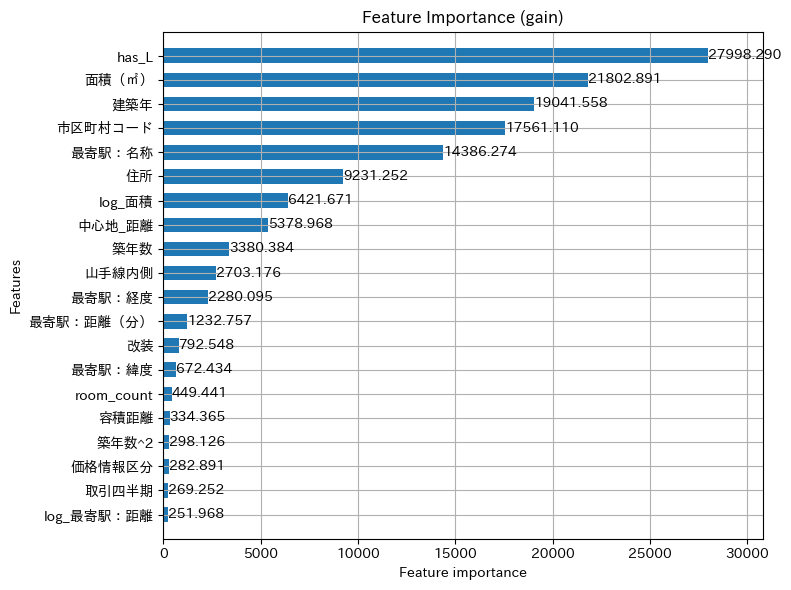

In [11]:
# 特徴量を可視化
fig, ax = plt.subplots(figsize=(8, 6))
lgb.plot_importance(
    booster,
    importance_type="gain",   # "split" に変えると分割回数ベース
    max_num_features=20,
    ax=ax,
    height=0.6,
)
ax.set_title("Feature Importance (gain)")
plt.tight_layout()
plt.show()

前処理パイプラインを実行中…（数十秒かかります）
前処理完了: (39659, 34)
SHAP 計算対象: (1000, 33)


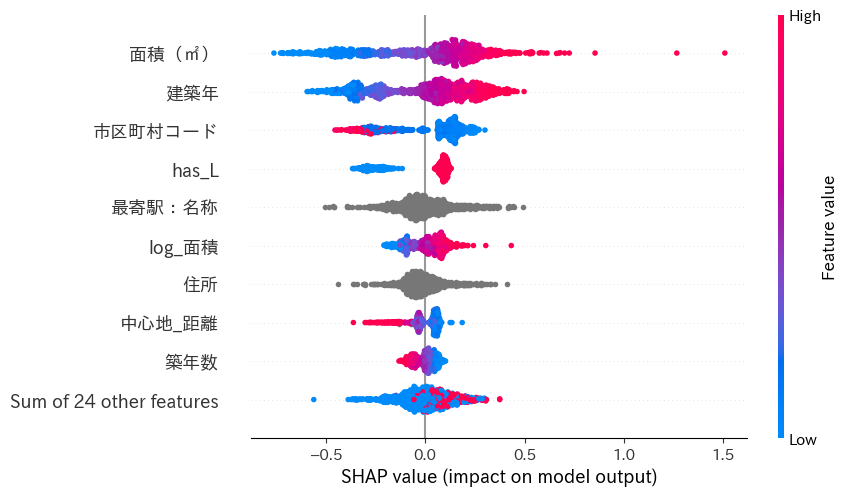

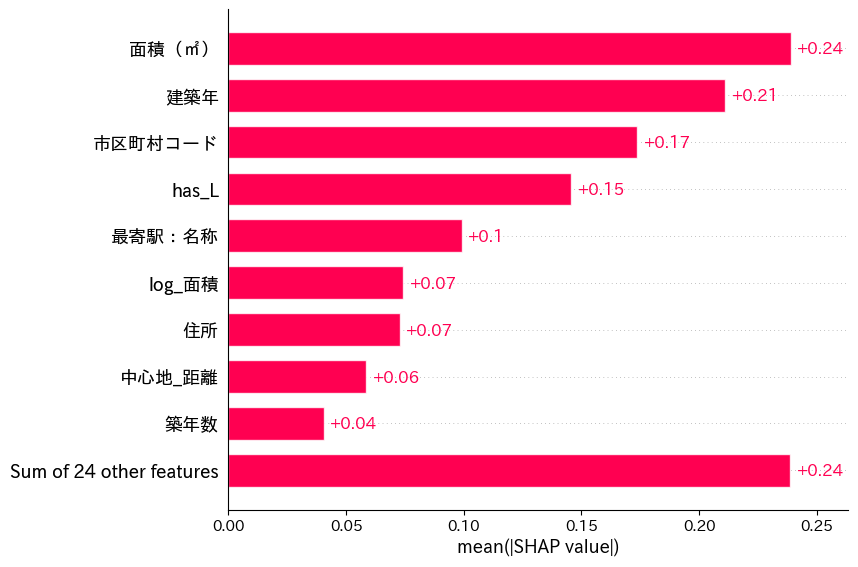

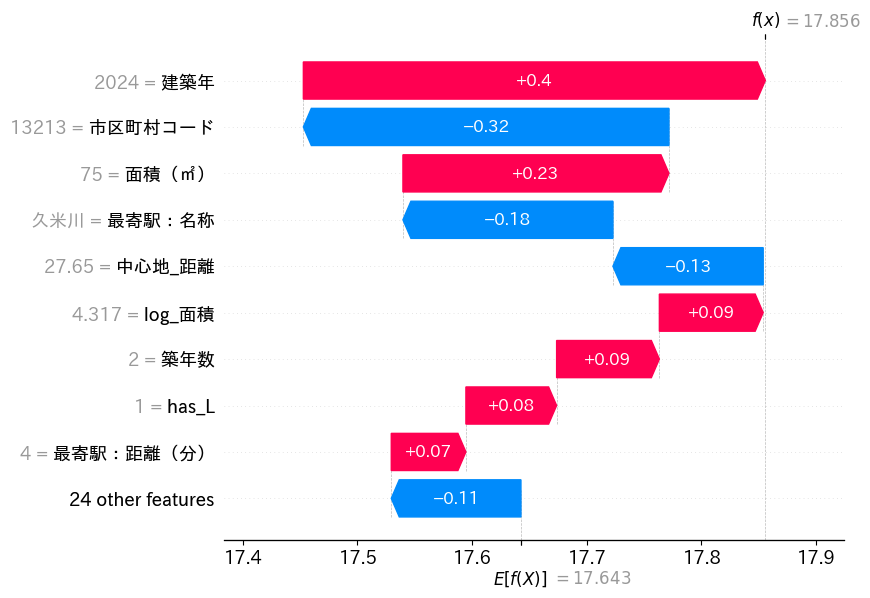

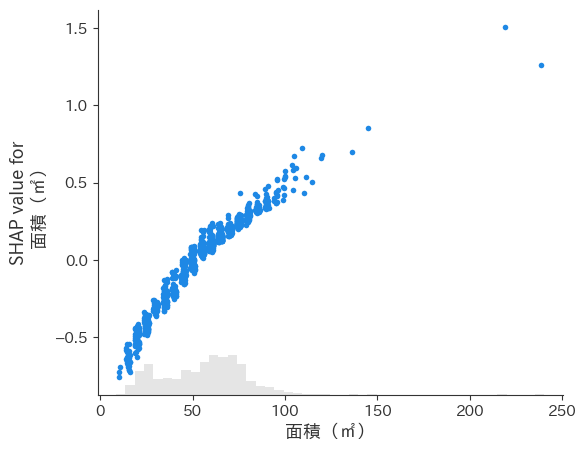

In [12]:
# shap値の計算

# 学習時と同じ前処理を再実行して、正しい dtype・カテゴリで特徴量を取得する
# （test_predictions.csv は予測結果なので CSV 経由で category 情報が落ちており、
#  そのままでは LightGBM の "categorical_feature do not match" エラーになる）
from src.preprocessing.run_pipeline import run_pipeline

print("前処理パイプラインを実行中…（数十秒かかります）")
df_features = run_pipeline()
print(f"前処理完了: {df_features.shape}")

# モデルが知っている特徴量列だけを、学習時と同じ順序で取り出す
X_for_shap = df_features[feat_names]

# 計算時間と描画負荷を抑えるためサンプリング
X_sample = X_for_shap.sample(n=1000, random_state=42)
print(f"SHAP 計算対象: {X_sample.shape}")

explainer = shap.TreeExplainer(booster)
sv = explainer(X_sample)  # Explanation オブジェクトを返す

# 大域的: 特徴量の効きと方向を一望（beeswarm）
shap.plots.beeswarm(sv)

# 大域的: 平均的な寄与の大きさで並べる
shap.plots.bar(sv)

# 局所的: 1件の予測の内訳
shap.plots.waterfall(sv[0])

# 依存関係: 1特徴量の値と寄与の関係（相互作用も色で表示）
shap.plots.scatter(sv[:, "面積（㎡）"])